In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 1000)


current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/"
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if file.endswith(".csv"):
          csv_path=directory+file
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          tot_dataframe = pd.concat([tot_dataframe,df])

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4

tot_dataframe['bandwidth_mbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']) #MB/s


/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/
/scratch/gsorrentino/tcuscan/temp_segscan_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_csr_gather_fp16.csv
      operator dtype      size  time_us  mem_bytes
0   csr_gather  fp16     81920    71.11     573440
1   csr_gather  fp16   2703360   103.00   18923520
2   csr_gather  fp16   5324800   161.90   37273600
3   csr_gather  fp16   7946240   218.80   55623680
4   csr_gather  fp16  10567680   276.90   73973760
5   csr_gather  fp16  13189120   328.35   92323840
6   csr_gather  fp16  15810560   366.52  110673920
7   csr_gather  fp16  18432000   404.12  129024000
8   csr_gather  fp16  21053440   438.80  147374080
9   csr_gather  fp16  23674880   471.17  165724160
10  csr_gather  fp16  26296320   494.44  184074240
11  csr_gather  fp16  28917760   539.98  202424320
12  csr_gather  fp16  31539200   566.44  220774400
13  csr_gather  fp16  34160640   606.92  239124480
14  

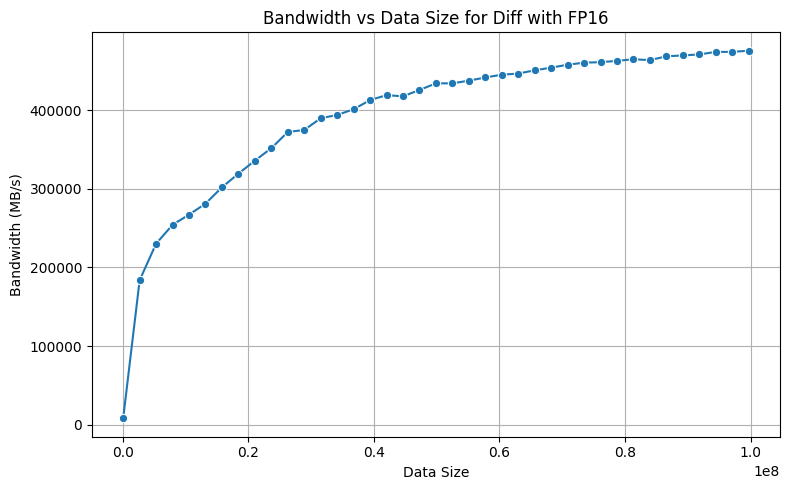

In [2]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_mbps', data=tot_dataframe, marker='o')

plt.xlabel('Data Size')
plt.ylabel('Bandwidth (MB/s)')
plt.title('Bandwidth vs Data Size for Diff with FP16')
plt.tight_layout()

plt.grid(True)
filename = "diff_fp16.pdf"
plt.savefig(filename)
plt.show()
